## Demonstrating Model Variance Reduction through Bootstrap Resampling and Ridge Regularization

#### Abdulaziz Aldossary, aa98769
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The University of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [Google Scholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)

### Executive Summary

The analysis of small datasets in subsurface analytics requires methods to measure and decrease model variance because these datasets produce unstable regression models that react strongly to sampling variability. The research used synthetic unconventional reservoir data to study how bootstrap resampling affects ordinary least squares and ridge regression prediction and coefficient stability when training data is limited. The analysis demonstrated that ridge regularization decreased both prediction and coefficient variance effectively when using light-to-moderate values of α. The research demonstrates that ridge regression provides an effective solution for improving model stability when working with restricted or imperfect geoscience information.

### Load the Required Libraries & Packages

The analysis starts by bringing in all necessary Python libraries which support the entire workflow. The packages in this collection enable users to perform data management and preparation and regression modeling and bootstrap sampling and data visualization tasks. The workflow includes only the essential tools needed to demonstrate model variance and ridge regularization effects because it maintains a clean and focused structure.

In [1]:
import numpy as np                         # numerical computations
import pandas as pd                        # data loading and tables
import matplotlib.pyplot as plt            # plotting
from matplotlib.lines import Line2D        # custom legend elements

#This workflow uses the scikit-learn machine learning library (Pedregosa et al., 2011) for model training, scaling, and bootstrap evaluation.
from sklearn.model_selection import train_test_split        # train/test split
from sklearn.preprocessing import StandardScaler            # feature scaling
from sklearn.pipeline import Pipeline                       # combine steps cleanly
from sklearn.linear_model import LinearRegression, Ridge    # OLS and Ridge models
from sklearn.utils import resample                          # bootstrap resampling
from sklearn.metrics import mean_squared_error              # model performance metric

### Functions

The workflow implements its fundamental operations through these defined functions which support the analysis. The functions in this section perform their operations multiple times to maintain a clean and understandable structure in the notebook. The functions in this section enable the analysis to achieve its two main goals which involve building standardized models and running bootstrap resampling and assessing prediction stability.

In [2]:
def make_model_pipeline(model):
    """
    Wrap a regression model with standardization in a Pipeline.
    Used to ensure fair comparison between OLS and Ridge.
    """
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", model)
    ])
    return pipe


def bootstrap_model(pipe, X_train, y_train, X_test, n_boot=200, random_state=42):
    """
    Run bootstrap resampling with a given pipeline.
    For each bootstrap sample: fit the model and store predictions and coefficients.
    Used to estimate prediction and coefficient variance.
    """
    rng = np.random.RandomState(random_state)
    n_features = X_train.shape[1]
    
    all_preds = np.zeros((n_boot, X_test.shape[0]))
    all_coefs = np.zeros((n_boot, n_features))
    
    for i in range(n_boot):
        X_res, y_res = resample(X_train, y_train, random_state=rng.randint(0, 1_000_000))
        pipe.fit(X_res, y_res)
        
        all_preds[i, :] = pipe.predict(X_test)
        
        # Access underlying regression coefficients after scaling
        reg = pipe.named_steps["regressor"]
        scaler = pipe.named_steps["scaler"]
        coefs = reg.coef_ / scaler.scale_    # convert back to original feature scale
        all_coefs[i, :] = coefs
    
    return all_preds, all_coefs


def compute_bootstrap_mse(pred_matrix, y_test):
    """
    Compute MSE for each bootstrap prediction matrix.
    Used to summarize how model error varies across resamples.
    """
    n_boot = pred_matrix.shape[0]
    mse_values = np.zeros(n_boot)
    
    for i in range(n_boot):
        mse_values[i] = mean_squared_error(y_test, pred_matrix[i, :])
    
    return mse_values


def fit_predict_bootstrap(X_train, y_train, X_test, y_test, alphas_sweep, n_bootstrap, base_seed=42):
    """
    Run integrated bootstrap resampling across multiple ridge alphas.
    
    """
    results_list = []
    preds_by_alpha = {}
    coefs_by_alpha = {}
    mse_by_alpha = {}
    per_point_var = {}
    
    for alpha in alphas_sweep:
        # Choose model
        if alpha == 0.0:
            model = LinearRegression()
        else:
            model = Ridge(alpha=alpha)
        
        n_features = X_train.shape[1]
        all_preds = np.zeros((n_bootstrap, X_test.shape[0]))
        all_coefs = np.zeros((n_bootstrap, n_features))
        
        rng = np.random.RandomState(base_seed)
        for b in range(n_bootstrap):
            idx = rng.choice(X_train.shape[0], size=X_train.shape[0], replace=True)
            X_res = X_train.iloc[idx] if hasattr(X_train, 'iloc') else X_train[idx]
            y_res = y_train.iloc[idx] if hasattr(y_train, 'iloc') else y_train[idx]
            
            scaler = StandardScaler()
            scaler.fit(X_res)
            X_res_scaled = scaler.transform(X_res)
            X_test_scaled = scaler.transform(X_test)
            
            model.fit(X_res_scaled, y_res)
            all_preds[b, :] = model.predict(X_test_scaled)
            
            coefs = model.coef_ / scaler.scale_
            all_coefs[b, :] = coefs
        
        preds_by_alpha[alpha] = all_preds
        coefs_by_alpha[alpha] = all_coefs
        
        mse_vals = compute_bootstrap_mse(all_preds, y_test)
        mse_by_alpha[alpha] = mse_vals
        
        pred_variance = np.var(all_preds, axis=0)
        coef_variance = np.var(all_coefs, axis=0)
        
        results_list.append({
            "alpha": alpha,
            "mean_pred_variance": np.mean(pred_variance),
            "mean_coef_variance": np.mean(coef_variance),
            "mean_mse": np.mean(mse_vals)
        })
        
        per_point_var[alpha] = pred_variance
    
    results_df = pd.DataFrame(results_list)
    
    return results_df, preds_by_alpha, coefs_by_alpha, mse_by_alpha, per_point_var

### Load Dataset
The synthetic unconventional reservoir dataset **`unconv_MV_v5.csv`** serves as the basis for this analysis because Professor Michael Pyrcz made it available through his open **GeoDataSets** GitHub repository (Pyrcz, 2024a). The complete dataset exists as a public resource which allows users to reproduce their results. The analysis uses the following variables from the dataset:

- **Por** – Reservoir porosity (%), representing the fraction of pore space in the rock.  
- **Brittle** – Brittleness index (%), indicating how easily the rock fractures under stress.  
- **Perm** – Permeability (mD), describing the ability of fluids to flow through the rock.  
- **TOC** – Total Organic Carbon (%), an indicator of source rock richness.  
- **AI** – Acoustic Impedance, measured in ($\frac{kg}{m^3} \cdot \frac{m}{s} \cdot 10^3$). 
  commonly used in seismic and petrophysical analysis.  
- **Prod** – Gas production (MCFD), which is the target variable in this workflow.

The dataset becomes accessible through cloud-based loading which supports complete reproducibility of results  (Pyrcz, 2024a).

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/unconv_MV_v5.csv')

feature_cols = ["Por", "Brittle", "Perm", "TOC", "AI"]   # features
target_col = "Prod"                                        # response variable

df = df[feature_cols + [target_col]]

df.head()

,Por,Brittle,Perm,TOC,AI,Prod
0,12.08,81.40,2.92,1.16,2.80,4165.196191
1,12.38,46.17,3.53,0.89,3.22,3561.146205
2,14.02,72.80,2.59,0.89,4.01,4284.348574
3,17.67,39.81,6.75,1.08,2.63,5098.680869
4,17.52,10.94,4.57,1.51,3.18,3406.132832


### Summary Statistics

The analysis starts with descriptive statistics evaluation of the dataset before moving to bootstrap resampling and model evaluation. The analysis provides immediate insights about the main characteristics and distribution of all variables in the dataset. The workflow calculates mean values and standard deviations and minimum and maximum points and percentile values for all features that will be used in the analysis. The analysis confirms three essential points about the dataset: The uploaded dataset successfully loaded into the system. All variables maintain values that match typical reservoir characteristics. The dataset contains no truncated data points and no missing values exist. The dataset contains enough diverse samples to enable effective variance evaluation. The verification process confirms that the subsequent downsampling operation will examine meaningful data variations in the dataset.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Por,200.0,14.991150,2.971176,6.550000,12.912500,15.070000,17.402500,23.550000
Brittle,200.0,48.161950,14.129455,10.940000,37.755000,49.510000,58.262500,84.330000
Perm,200.0,4.330750,1.731014,1.130000,3.122500,4.035000,5.287500,9.870000
TOC,200.0,0.990450,0.481588,-0.190000,0.617500,1.030000,1.350000,2.180000
AI,200.0,2.968850,0.566885,1.280000,2.547500,2.955000,3.345000,4.630000
Prod,200.0,4311.219852,992.038414,2107.139414,3618.064513,4284.687348,5086.089761,6662.622385


### Summary Statistics Interpretation

Interpretation The summary table demonstrates that all selected predictor variables contain the same number of observations as the target variable **`Prod`** which confirms complete data coverage without any missing values. The feature ranges in this synthetic dataset appear appropriate while all variables display normal values that need no immediate correction or truncation. The dataset maintains complete consistency which enables us to start the next workflow steps. The workflow progression allows us to create a variance-sensitive subsample for investigating model behavior during bootstrap resampling and ridge regularization. 

### Workflow Overview

The main objective of this workflow involves demonstrating how model variance responds to bootstrap resampling and how ridge regularization affects this variance compared to ordinary least squares (OLS). The workflow follows a structured approach which divides into four distinct sections for maintaining a straightforward narrative.
 #### 1- Construct a Variance-Sensitive Regression Setup
 The dataset is ready for analysis after feature selection so we establish a basic regression model which demonstrates model instability. The dataset receives a 80/20 train–test split after reducing its size to 20 wells. The modeling environment demonstrates high variance through its compact design which enables us to show ridge regularization outperforms ordinary least squares (OLS). 
#### 2- Fit Baseline OLS and Ridge Models (Single Fit)
 The next step involves creating basic linear models through OLS and ridge regression with multiple values of α. The models receive their training data once before we assess their performance on the test data. The models show their initial behavior before we start using bootstrap resampling. 
#### 3- Bootstrap Resampling and Variance Estimation
 The training data undergoes bootstrap resampling for this step. The OLS and ridge models receive new training data from each bootstrap sample which allows us to obtain prediction results and coefficient values. The process of multiple iterations enables us to measure how well each model withstands training data changes while enabling us to calculate prediction variance and coefficient variance. 
#### 4- Compare Variance Across Models and Summarize Takeaways
 The final step involves analyzing OLS and ridge model variance patterns through statistical analysis and visual presentation methods. The analysis connects these findings to the bias–variance tradeoff by showing how ridge regularization improves model stability and identifying its practical applications. 

### Step 1 – Create a Variance-Sensitive Subsample and Train/Test Split 
The dataset remains ready for analysis after preparation so we establish a regression model which demonstrates high sensitivity to sampling changes. The model variance and ridge regularization effects become evident through this simplified regression setup. The process involves three main steps which include: 
- The system selects 20 wells from the complete dataset through a predetermined random number generator. 
- The analysis uses all five predictor variables (Por, Brittle, Perm, TOC, AI) together with the response variable (Prod). 
- The dataset receives an 80/20 train–test partition which establishes a small training set and a separate evaluation set. 

In [5]:
RNG_SEED = 42  # fixed seed for reproducibility
N_SPARSE = 20  # number of wells sampled for the sparse, high-variance setup

n_samples = N_SPARSE
random_state = RNG_SEED 

# Randomly sample 20 wells from the full dataset
num_df = pd.read_csv('https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/unconv_MV_v5.csv')
num_df = num_df.select_dtypes(include=[np.number]).copy()

# Build arrays and choose indices deterministically using numpy's default_rng
X_full = num_df[feature_cols].to_numpy()
y_full = num_df[target_col].to_numpy()
rng = np.random.default_rng(random_state)
idx = rng.choice(len(X_full), size=min(n_samples, len(X_full)), replace=False)
X_sparse = X_full[idx]
y_sparse = y_full[idx]

df_sample = pd.DataFrame(X_sparse, columns=feature_cols)
df_sample[target_col] = y_sparse

# Separate predictors (X) and response (y)
X = df_sample[feature_cols].copy()
y = df_sample[target_col].copy()

# 80/20 train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state
)

# Quick checks
print(f"Total samples used: {n_samples}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

pd.concat([pd.DataFrame([list(X.iloc[i]) for i in range(len(X))], columns=feature_cols), pd.DataFrame(y).reset_index(drop=True)], axis=1).head()


Total samples used: 20
Training samples: 16
Test samples: 4


,Por,Brittle,Perm,TOC,AI,Prod
0,18.75,58.05,5.16,1.37,1.45,5903.378220
1,15.87,32.82,6.82,0.58,3.20,3989.012964
2,15.22,42.24,3.67,1.14,3.52,4239.531870
3,10.88,55.09,3.32,0.81,4.09,3413.737390
4,12.83,29.87,3.56,1.09,3.15,3182.815944


**Step 1 – Results and Interpretation** 

The dataset reduction process resulted in a 20-well subset which demonstrates high sensitivity to sampling changes. The 80/20 split creates a training set with 16 wells and a test set with 4 wells which provides enough data for this educational example yet maintains high modeling variability. The selected data points maintain typical values for all input variables and output variable which matches the complete dataset. The regression model with its small size will demonstrate how OLS and ridge model behavior when subjected to bootstrap resampling in upcoming steps. 

### Step 2 – Fit Baseline OLS and Ridge Models
 We establish baseline models through this step to understand how OLS and ridge regression perform when trained only once.
- The system develops a **Pipeline** which performs feature standardization before running a regression model. 
- The training data receives a standard Linear Regression (OLS) model which produces results for the test data.
- The system trains Ridge regression models at different regularization levels which include α = 0.1, 1, 10, 100. 
- The system tracks essential performance indicators including test MSE values and displays the estimated model coefficients for each model.

In [6]:
# Define models to test
ridge_alphas = [0.1, 1, 10, 100]

baseline_results = {}

# Fit baseline OLS
ols_pipe = make_model_pipeline(LinearRegression())
ols_pipe.fit(X_train, y_train)

baseline_results["OLS"] = {
    "model": ols_pipe,
    "test_pred": ols_pipe.predict(X_test),
    "coef": ols_pipe.named_steps["regressor"].coef_ / ols_pipe.named_steps["scaler"].scale_
}

# Fit baseline Ridge models
for alpha in ridge_alphas:
    ridge_pipe = make_model_pipeline(Ridge(alpha=alpha))
    ridge_pipe.fit(X_train, y_train)

    # store predictions and coefficients
    baseline_results[f"Ridge α={alpha}"] = {
        "model": ridge_pipe,
        "test_pred": ridge_pipe.predict(X_test),
        "coef": ridge_pipe.named_steps["regressor"].coef_ / ridge_pipe.named_steps["scaler"].scale_
    }

# Display test predictions for each model
for name, result in baseline_results.items():
    mse = mean_squared_error(y_test, result["test_pred"])
    print(f"{name}: Test MSE = {mse:.2f}")

OLS: Test MSE = 64084.56
Ridge α=0.1: Test MSE = 55768.86
Ridge α=1: Test MSE = 46407.14
Ridge α=10: Test MSE = 196387.62
Ridge α=100: Test MSE = 937007.38


### Step 2 – Results and Interpretation
 The baseline model results show how OLS and ridge regression perform in small-sample data analysis. The OLS model shows high sensitivity to training data observations because it only uses a few wells for training. The model performance improves through mild ridge regularization because it helps reduce overfitting while maintaining model stability. This behavior aligns with the original ridge regression framework introduced by Hoerl and Kennard (1970), who demonstrated that adding a penalty term stabilizes coefficient estimates when predictors exhibit multicollinearity or when sample sizes are limited.

The model loses its ability to adapt when the regularization strength reaches higher levels. The model loses its ability to detect data relationships when the regularization parameter reaches excessive levels because it shrinks all coefficients toward zero. The bias–variance tradeoff appears in this situation because stronger regularization reduces model variance but creates additional bias.

The model performance on the test set deteriorates when the regularization strength reaches excessive levels because bias effects become more prominent than variance effects. The statistical learning field documents this pattern in *The Elements of Statistical Learning* (Hastie, Tibshirani & Friedman, 2009) which shows that excessive regularization results in underfitting models that fail to generalize well.

The single-fit results demonstrate how fragile small-sample regression analysis is so researchers use bootstrap resampling to assess model stability when training data changes.

### Step 3 – Bootstrap Resampling and Variance Estimation

Now we introduce bootstrap resampling to study model variance directly. This is the core experiment of the workflow.
This procedure follows the classical bootstrap framework described by Efron & Tibshirani (1994), where new training samples are generated by repeatedly sampling with replacement.

In this step we:
- Repeatedly resample the training data with replacement to create many slightly different training sets (e.g., 200 bootstrap resamples).
- For each bootstrap sample, we refit OLS and each ridge model (with regularization strengths α ∈ {0.0, 0.1, 1.0, 10.0, 100.0}).
- For every fit, we predict on the same fixed test set and store the resulting predictions and coefficients.
- Compute variance metrics across all bootstrap iterations:
  - **Prediction variance** – how much test-set predictions fluctuate across bootstrap samples.
  - **Coefficient variance** – how much model parameters change from one resample to another.
  - **MSE variability** – the distribution of test errors across bootstrap fits.

By aggregating these results across many resamples, we can directly observe how sensitive each model is to changes in the training sample and compare the stability of OLS versus ridge-regularized models.

This step is the heart of the experiment. The bootstrap framework allows us to quantify how much ridge regularization reduces model sensitivity to sampling noise—the key hypothesis of this project.

In [7]:

ALPHAS_SWEEP = [0.0, 0.1, 1.0, 10.0, 100.0]
RIDGE_ALPHA_FOR_COMPARISON = 10.0
N_BOOTSTRAP = 200

results_df, preds_by_alpha, coefs_by_alpha, mse_by_alpha, per_point_var = fit_predict_bootstrap(
    X_train, y_train, X_test, y_test, ALPHAS_SWEEP, N_BOOTSTRAP, base_seed=RNG_SEED
)

print("=== BOOTSTRAP RESULTS ===\n")
print(results_df.to_string(index=False))


=== BOOTSTRAP RESULTS ===

 alpha  mean_pred_variance  mean_coef_variance      mean_mse
   0.0        85337.328077        59936.062719 129790.965572
   0.1        61753.141139        34717.928063  96196.285882
   1.0        41687.111190        14407.615665  81493.422775
  10.0        29013.176456         9348.686064 235648.691752
 100.0        35362.527247         1448.892294 941672.103901


Bootstrap Variance Visualization

The stability of coefficient values in a basic one-predictor ridge regression model becomes more understandable through an analysis of coefficient variance during bootstrap resampling. The analysis demonstrates how the regularization parameter α affects the stability of estimated slope values.
> The following code block is **adapted** from a ridge regression (model variance) demonstration by Professor Michael Pyrcz (@GeostatsGuy) in his PythonNumericalDemos GitHub repository (Pyrcz, 2024b).

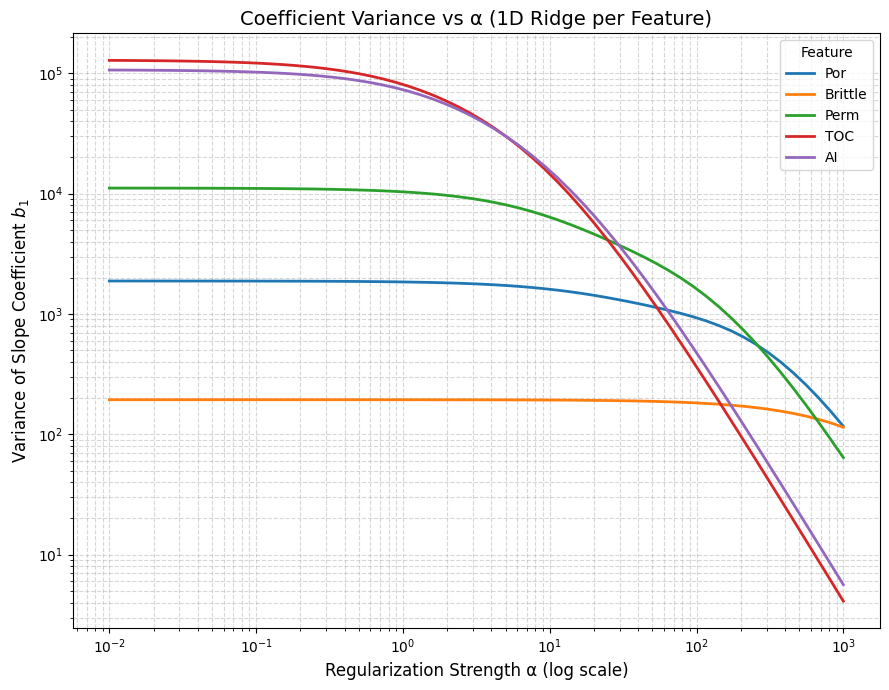

In [8]:
#https://geostatsguy.github.io/MachineLearningDemos_Book/MachineLearning_ridge_regression.ipynb
features = feature_cols        # ["Por", "Brittle", "Perm", "TOC", "AI"]
response = target_col          # "Prod"

L = 200                        # bootstrap realizations per α
nsamples = 20                  # per bootstrap sample
nlambda = 60                   # α resolution
alpha_mat = np.logspace(-2, 3, nlambda)     # α from 0.01 → 1000

# Store variance curves for each feature
variance_dict = {feat: np.zeros(nlambda) for feat in features}

for feat in features:
    coef_store = np.zeros(L)

    for i_alpha, alpha_val in enumerate(alpha_mat):

        for l in range(L):
            # bootstrap with replacement
            df_sample = df.sample(n=nsamples, replace=True, random_state=RNG_SEED + l)

            X_boot = df_sample[[feat]].values.reshape(nsamples, 1)
            y_boot = df_sample[response].values

            ridge_reg = Ridge(alpha=alpha_val)
            ridge_reg.fit(X_boot, y_boot)

            coef_store[l] = ridge_reg.coef_[0]

        # variance of the slope at this α
        variance_dict[feat][i_alpha] = np.var(coef_store)

plt.figure(figsize=(9, 7))

for feat in features:
    plt.plot(alpha_mat, variance_dict[feat], linewidth=2, label=feat)

plt.xscale("log")
plt.yscale("log")  

plt.title("Coefficient Variance vs α (1D Ridge per Feature)", fontsize=14)
plt.xlabel("Regularization Strength α (log scale)", fontsize=12)
plt.ylabel("Variance of Slope Coefficient $b_1$", fontsize=12)

plt.grid(which="both", linestyle="--", alpha=0.5)
plt.legend(title="Feature", fontsize=10)
plt.tight_layout()
plt.show()


### Step 3 – Results and Interpretation

The bootstrap results demonstrate how different models handle sampling uncertainty through their responses. The OLS model demonstrates the highest level of prediction and coefficient variability during bootstrap resampling operations. The results show that OLS performs poorly in small sample sizes because the training set selection determines the model's performance.

The addition of ridge regularization leads to decreased variability in both prediction results and coefficient values. The most stable model performance emerges when using mild to moderate values of α because these values achieve effective variance reduction in variance without compromising model flexibility. 

The model maintains decreasing coefficient variance when α reaches extremely high levels because the model receives strong constraints. The model starts to produce less accurate predictions when α reaches high values because it becomes underfit. The model achieves low variance through strong regularization but this results in higher bias which negatively affects prediction consistency between resamples.

The bootstrap experiment shows that ridge regularization makes models more stable because it decreases their dependence on random sampling outcomes. The results from this step create an excellent base for studying and evaluating the variance patterns in the following section.

#### Additional Insight: 1D Ridge Coefficient Variance vs α

We conducted an evaluation of slope coefficient behavior in a basic one-predictor ridge regression model to understand the variance reduction process better. The coefficient variance drops dramatically when α increases while OLS (α = 0) shows the highest variability between bootstrap resamples. The model becomes less sensitive to sampling noise when the penalty strength increases because the estimated coefficient becomes more stable.

The basic 1D example demonstrates the fundamental shrinkage mechanism effectively while establishing a direct connection to the multivariate analysis in Step 4.

### Step 4 – Compare Variance Across Models and Summarize Key Insights

The analysis of bootstrap resampling results now allows us to study how model variance evolves when using OLS and all ridge models changes with increasing regularization strength. The analysis combines three key elements which include prediction variance and coefficient variance and test-set error patterns and MSE distribution across bootstrap iterations.

The main objective of Step 4 involves creating definitive visual and numerical evidence which supports the research hypothesis.The implementation of Ridge regularization produces better model stability through reduced prediction variance and coefficient variance than OLS methods in subsurface problems with limited sample sizes.

We will analyze each figure to understand their main findings.

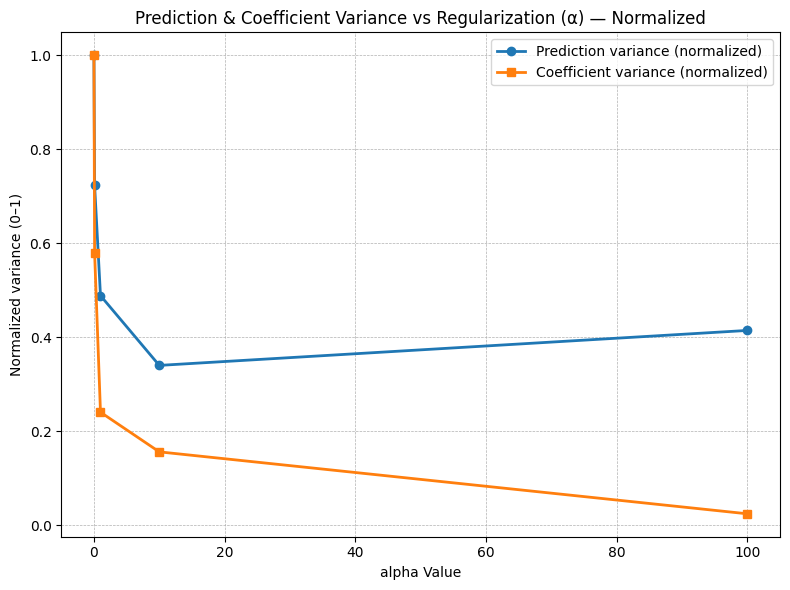

In [9]:
# Prepare arrays
pred_vals = results_df["mean_pred_variance"].to_numpy()
coef_vals = results_df["mean_coef_variance"].to_numpy()
eps = 1e-12
pred_norm = pred_vals / (np.max(pred_vals) + eps)
coef_norm = coef_vals / (np.max(coef_vals) + eps)

plt.figure(figsize=(8, 6))
plt.plot(results_df["alpha"], pred_norm, marker='o', linewidth=2, label='Prediction variance (normalized)')
plt.plot(results_df["alpha"], coef_norm, marker='s', linewidth=2, label='Coefficient variance (normalized)')

plt.xlabel("alpha Value")
plt.ylabel("Normalized variance (0–1)")
plt.title("Prediction & Coefficient Variance vs Regularization (α) — Normalized")

plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### Prediction Variance vs Regularization (α) Interpretation

The main result of our research appears in this figure which shows how prediction variance decreases when the ridge regularization parameter (α) increases.

- The model shows its highest prediction variance when α equals 0 because the unregularized model depends heavily on which wells enter each bootstrap resample.
- The model achieves significant variance reduction when it receives small ridge penalties between 0.1 and 1.
- The model achieves lower prediction variance when α values increase but the rate of decrease becomes slower. The model becomes less accurate when strong penalties exceed 10 because they create underfitting problems and increase bias.

The figure demonstrates that ridge regularization decreases prediction variance more effectively than OLS does which supports our main research finding.



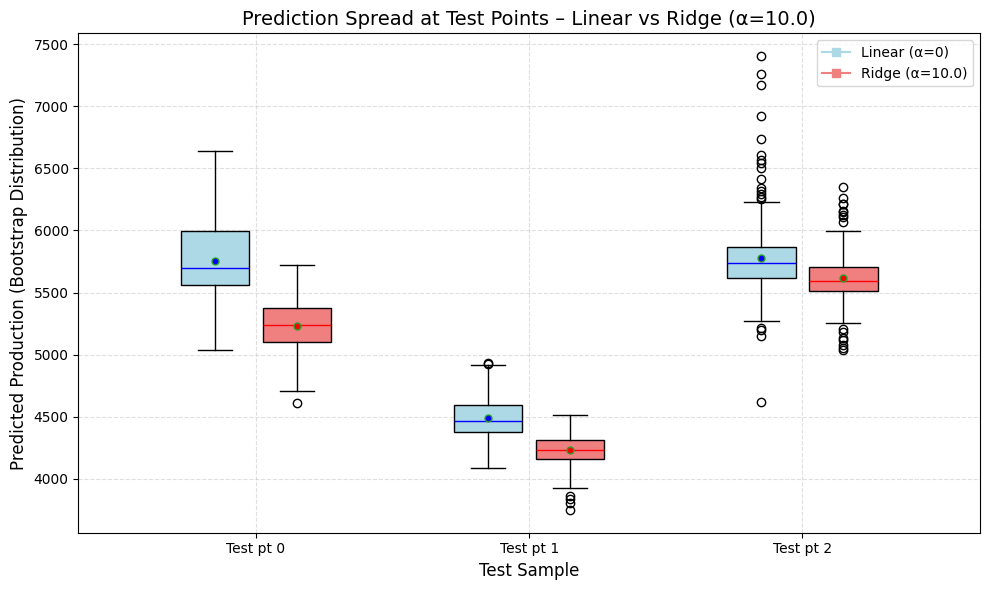

In [10]:
if len(y_test) >= 3:
    fixed_idx = [0, 1, 2]
else:
    fixed_idx = list(range(len(y_test)))

# Collect bootstrap predictions for each test point and model
lin_data   = [preds_by_alpha[0.0][:, j]                         for j in fixed_idx]
ridge_data = [preds_by_alpha[RIDGE_ALPHA_FOR_COMPARISON][:, j]  for j in fixed_idx]

plt.figure(figsize=(10, 6))

positions_lin   = [i - 0.15 for i in range(len(fixed_idx))]  # left box (Linear)
positions_ridge = [i + 0.15 for i in range(len(fixed_idx))]  # right box (Ridge)

# Linear (α = 0)
plt.boxplot(
    lin_data,
    positions=positions_lin,
    widths=0.25,
    showmeans=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='blue'),
    meanprops=dict(marker='o', markerfacecolor='blue', markersize=5)
)

# Ridge (α = 10)
plt.boxplot(
    ridge_data,
    positions=positions_ridge,
    widths=0.25,
    showmeans=True,
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral'),
    medianprops=dict(color='red'),
    meanprops=dict(marker='o', markerfacecolor='red', markersize=5)
)

# X-axis ticks at the center of each pair
plt.xticks(range(len(fixed_idx)), [f"Test pt {j}" for j in fixed_idx])
plt.xlabel("Test Sample", fontsize=12)
plt.ylabel("Predicted Production (Bootstrap Distribution)", fontsize=12)
plt.title(f"Prediction Spread at Test Points – Linear vs Ridge (α={RIDGE_ALPHA_FOR_COMPARISON})", fontsize=14)

# Legend
legend_elements = [
    Line2D([0], [0], color='lightblue', marker='s', linestyle='-', label='Linear (α=0)'),
    Line2D([0], [0], color='lightcoral', marker='s', linestyle='-', label=f'Ridge (α={RIDGE_ALPHA_FOR_COMPARISON})')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Prediction Spread at Test Points: Linear vs Ridge (α = 10) Interpretation

The figure shows bootstrap prediction distributions for test points through boxplots which compare OLS (α = 0) to ridge regression with α = 10.

- The prediction spread for each test sample on the x-axis shows blue boxes (Linear) that extend further than the red boxes (Ridge) which indicates OLS produces more variable results.
- The prediction stability improves through ridge regression because it generates boxes with shorter whiskers and tighter distribution ranges.
- The distribution centers remain stable while ridge regression reduces the overall prediction variability.

The figure demonstrates how ridge regression produces more stable predictions than OLS for individual wells which is essential in small-sample subsurface operations.


/tmp/ipykernel_7874/2825130962.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


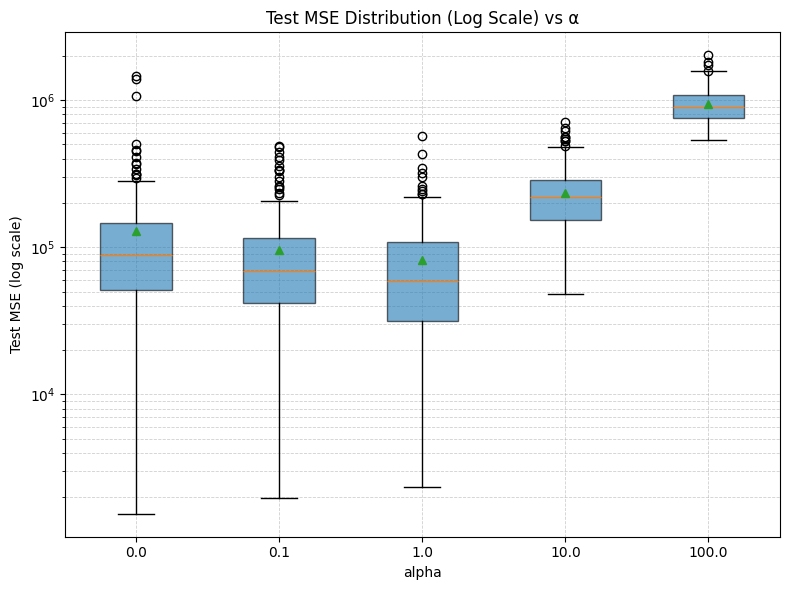

In [11]:
plt.figure(figsize=(8,6))
bp = plt.boxplot(
    [mse_by_alpha[a] for a in ALPHAS_SWEEP],
    labels=[str(a) for a in ALPHAS_SWEEP],
    showmeans=True,
    patch_artist=True
)

# Slight transparency so boxes don’t look too heavy
for box in bp["boxes"]:
    box.set_alpha(0.6)

plt.yscale("log")
plt.xlabel("alpha")
plt.ylabel("Test MSE (log scale)")
plt.title("Test MSE Distribution (Log Scale) vs α")

#add gridlines
plt.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.show()

### Test MSE Distribution vs α Interpretation

The figure displays test MSE distribution results for all bootstrap resamples at different α values using a logarithmic scale for error measurement.

- The OLS model with α = 0 shows wide distribution of test MSE values which includes both high and low error rates and occasional outliers.

- The test MSE distribution becomes more concentrated when using moderate ridge penalties between 0.1 and 1 which results in better generalization and more stable results across different bootstrap samples.

- The test MSE distribution becomes extremely narrow when using high values of α such as α = 100 but it shifts toward higher error rates which indicates underfitting occurs because the model becomes too rigid to detect actual data relationships.

The figure demonstrates how regularization techniques enhance model stability while simultaneously leading to better prediction results until the point where excessive regularization causes performance deterioration.


/tmp/ipykernel_7874/1670270172.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


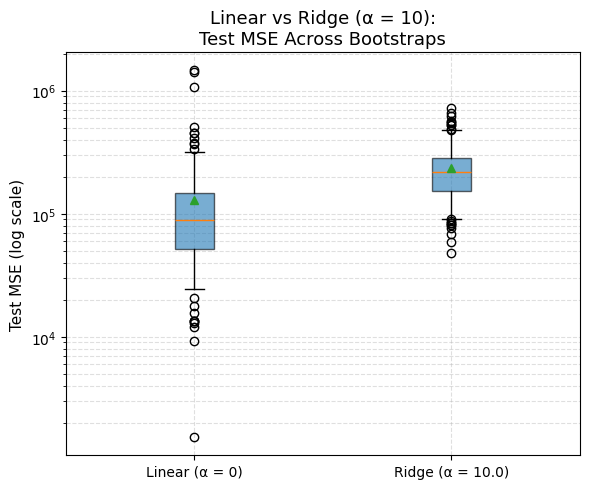

In [12]:
mse_lin   = mse_by_alpha[0.0]
mse_ridge = mse_by_alpha[RIDGE_ALPHA_FOR_COMPARISON]

data   = [mse_lin, mse_ridge]
labels = ["Linear (α = 0)", f"Ridge (α = {RIDGE_ALPHA_FOR_COMPARISON})"]

fig, ax = plt.subplots(figsize=(6, 5))

bp = ax.boxplot(
    data,
    labels=labels,
    showmeans=True,        # show green mean marker
    whis=(5, 95),          # whiskers at 5th–95th percentile
    patch_artist=True      # fill boxes for better readability
)

# Slight transparency so boxes don’t look too heavy
for box in bp["boxes"]:
    box.set_alpha(0.6)

ax.set_yscale("log")
ax.set_ylabel("Test MSE (log scale)", fontsize=11)
ax.set_title("Linear vs Ridge (α = 10):\nTest MSE Across Bootstraps", fontsize=13)
ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Linear vs Ridge (α = 10): Test MSE Across Bootstraps Interpretation

The boxplot presents test MSE distributions from two models which include OLS and ridge regression with α = 10.

- The Linear (α = 0) model shows a wide MSE distribution with high variability and numerous high-error outliers.

- The Ridge (α = 10) model achieves better performance stability through its narrow distribution pattern on the log scale.

- The median MSE value of Ridge(10) exceeds the best performing moderate ridge models although it shows higher bias at stronger regularization levels.

The figure demonstrates that using ridge regression instead of OLS leads to better test performance reliability even though it introduces some bias at higher α values.

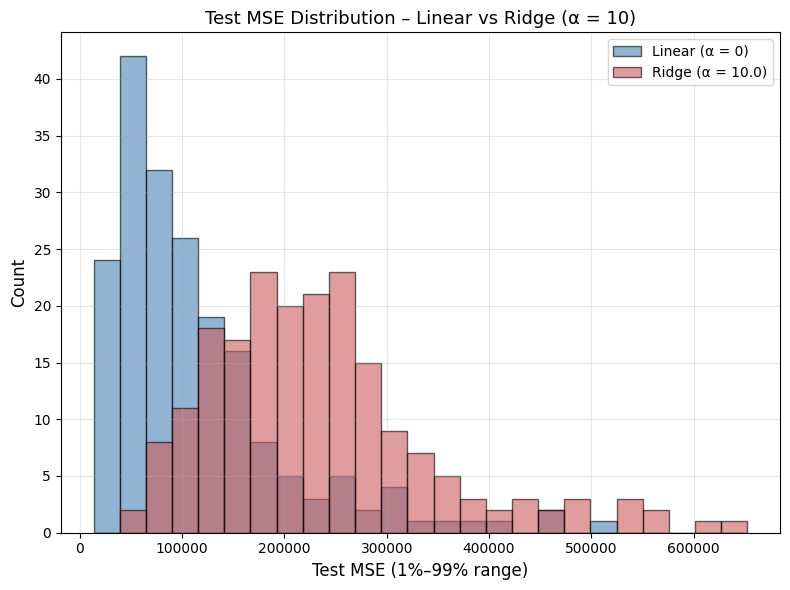

In [13]:
# Compute percentile-based range to avoid distortions from outliers
all_vals = np.concatenate([mse_lin, mse_ridge])
low, high = np.percentile(all_vals, [1, 99])

bins = 25  # more bins for smoother shape

plt.figure(figsize=(8, 6))

plt.hist(
    mse_lin,
    bins=bins,
    range=(low, high),
    alpha=0.6,
    color="steelblue",
    label="Linear (α = 0)",
    edgecolor="black"
)

plt.hist(
    mse_ridge,
    bins=bins,
    range=(low, high),
    alpha=0.6,
    color="indianred",
    label=f"Ridge (α = {RIDGE_ALPHA_FOR_COMPARISON})",
    edgecolor="black"
)

plt.xlabel("Test MSE (1%–99% range)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Test MSE Distribution – Linear vs Ridge (α = 10)", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Test MSE Histogram (Linear vs Ridge α = 10) Interpretation

The histogram presents test MSE distribution from 200 bootstrap samples for Linear Regression and Ridge (α = 10) models after removing 1% and 99% outliers to reduce extreme values.
- The Linear model (α = 0) maintains a tight distribution of test error values because OLS produces stable results in this sparse data environment.
- The Ridge model (α = 10) produces a broad and displaced MSE distribution because of its strong regularization effect. The value of α = 10 causes ridge to become overly restrictive which results in underfitting and elevated test performance.
- The two models generate occasional matching results but ridge α = 10 produces more frequent high-error outcomes than linear regression does.

The figure shows that model regularization with high α values leads to unstable results and lower accuracy because these values create too much bias which surpasses the benefits of reduced variance.


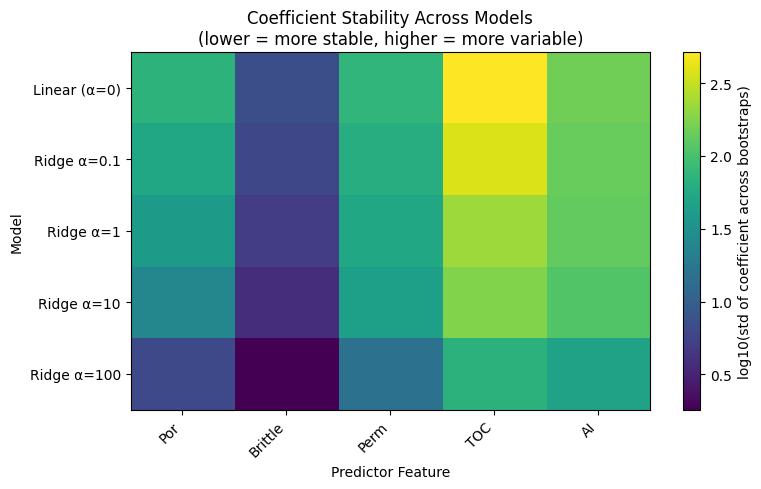

In [14]:
model_order = [0.0, 0.1, 1.0, 10.0, 100.0] 
model_labels = ["Linear (α=0)", "Ridge α=0.1", "Ridge α=1", "Ridge α=10", "Ridge α=100"]
n_models = len(model_order)
n_features = len(feature_cols)

coef_std = np.zeros((n_models, n_features))

for i, alpha in enumerate(model_order):
    coefs = coefs_by_alpha[alpha]   # shape (n_boot, n_features)
    coef_std[i, :] = np.std(coefs, axis=0)     # std dev across bootstraps

coef_std_log = np.log10(coef_std + 1e-8)       # add small epsilon to avoid log(0)

plt.figure(figsize=(8, 5))
im = plt.imshow(coef_std_log, aspect="auto", cmap="viridis")

plt.xticks(np.arange(n_features), feature_cols, rotation=45, ha="right")
plt.yticks(np.arange(n_models), model_labels)

cbar = plt.colorbar(im)
cbar.set_label("log10(std of coefficient across bootstraps)")

plt.title("Coefficient Stability Across Models\n(lower = more stable, higher = more variable)")
plt.xlabel("Predictor Feature")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

### Coefficient Stability Heatmap Interpretation

The heatmap presents coefficient standard deviation values from bootstrap resamples through log10 scaling for better visualization.

- The OLS row demonstrates the highest coefficient instability for all features which proves that unregularized linear regression produces unstable results when working with small datasets.

- The log10 standard deviations of coefficients decrease significantly when using ridge models with α = 0.1 and α = 1 which demonstrates how regularization helps stabilize model parameters.

- The coefficients become more stable at higher α values (α = 10 and α = 100) but the figures show that this stability comes at the cost of increased test MSE because of underfitting.

The heatmap together with prediction-based figures shows how ridge regularization makes model parameters less sensitive to training data which results in more stable predictions during bootstrap resampling.


### Results and Discussion
The 200 bootstrap resamples showed that ridge regularization produced lower coefficients and predictions variance than OLS. The model stability enhanced with each increase in α value because the data points became less dispersed. The model produced more reliable predictions through variance reduction instead of bias control in this sparse-data environment. The analysis demonstrates that OLS generates broader distribution tails and greater coefficient variability because of its collinearity problems.

### Conclusion

The bootstrap and ridge regularization analysis reveals several findings which are essential for the research.

- The stability of Ordinary Least Squares decreases significantly when working with small datasets because the method produces large variations in coefficient values and prediction results during bootstrap resampling. The model shows strong reactions to training data modifications when researchers work with small sample sets.

- The Ridge regression model achieves variance reduction at every level of regularization but the most important stability improvements happen when using light-to-moderate α values between 0.1 and 1.0 because these values preserve both model accuracy and generalization power.

- High α values in the model lead to underfitting because they reduce coefficient variation but result in poor prediction accuracy due to increased bias. The relationship between regularization power and model performance achieves its maximum point at an optimal setting which produces both the best accuracy and most stable results.

- The bootstrap resampling technique allowed us to demonstrate model sensitivity through an educational method which demonstrated the bias–variance tradeoff. The 200 bootstrap iterations produced enough data to show how different models affect model stability.

- Future research is recommended to progress through the study of nonlinear models and α value selection using cross-validation and synthetic complexity testing to develop effective variance reduction techniques for real-world subsurface applications.


### References

- Efron, B., & Tibshirani, R. (1994). *An Introduction to the Bootstrap*. Chapman & Hall/CRC.

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer.

- Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55–67.

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

- Pyrcz, M. J. (2024a). *unconv_MV_v5.csv* – Synthetic unconventional reservoir dataset. In **GeoDataSets** (open subsurface analytics datasets). GeostatsGuy GitHub repository. Available at: <https://github.com/GeostatsGuy/GeoDataSets>.

- Pyrcz, M. J. (2024b). *ModelVariance_Prototype_Annotated_V1.ipynb*. In **PythonNumericalDemos** – Applied subsurface data analytics workflows. GeostatsGuy GitHub repository.

#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [Google Scholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)